Assignment 8

task 1

Simulate a Bernoulli trial in Python to model whether a user successfully logs into their Zomato account (success=1, failure=0) with a given probability of success p=0.85. Run the simulation 20 times and print the results.

In [1]:
import numpy as np

np.random.seed(42)  # for reproducible results

p_success = 0.85
num_trials = 20

# Each trial is Bernoulli(p): 1 = successful login, 0 = failed login
login_results = np.random.binomial(n=1, p=p_success, size=num_trials)

print("Login results (1 = success, 0 = failure):")
print(login_results)

print(f"\nNumber of successes: {np.sum(login_results)} out of {num_trials}")
print(f"Observed success rate: {np.mean(login_results)}")


Login results (1 = success, 0 = failure):
[1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1]

Number of successes: 17 out of 20
Observed success rate: 0.85


**Explanation:** A Bernoulli trial has only two possible outcomes: success (1) or failure (0), with a fixed probability p of success. Here we simulate 20 independent login attempts, each with p=0.85 chance of succeeding, using `np.random.binomial(n=1, p=0.85, size=20)` (a binomial with n=1 trial is exactly a Bernoulli trial). The observed success rate from the simulation should be close to 0.85, though it won't be exact since this is a random simulation with only 20 trials.

task 2

Write a Python function that uses the binomial distribution to calculate the probability of getting exactly 3 successful UPI payments out of 5 attempts on Paytm, if the success rate per payment is 0.9.

**Hint:** Use scipy.stats.binom.pmf for the calculation.

In [2]:
from scipy.stats import binom

def binomial_probability(n, k, p):
    """
    Returns P(X = k) for a Binomial(n, p) distribution using scipy's pmf function.
    n = number of trials, k = number of successes, p = probability of success per trial
    """
    return binom.pmf(k, n, p)

# 5 UPI payment attempts, want exactly 3 successes, success rate 0.9 per payment
n_attempts = 5
k_successes = 3
p_success = 0.9

result = binomial_probability(n_attempts, k_successes, p_success)

print(f"P(exactly {k_successes} successes out of {n_attempts} attempts) = {round(result, 4)}")


P(exactly 3 successes out of 5 attempts) = 0.0729


**Explanation:** The binomial distribution models the number of successes in a fixed number of independent Bernoulli trials, each with the same success probability p. Here n=5 payment attempts and p=0.9 success rate per attempt. Using `binom.pmf(k=3, n=5, p=0.9)`, we get the probability of getting exactly 3 successful payments out of 5, which comes out to about 0.0729 (roughly 7.3%). This is fairly low because with such a high success rate (0.9), getting only 3 out of 5 right is less likely than getting 4 or all 5 correct.

task 3

Suppose the average number of new playlist creations per minute on Spotify is 4. Use the Poisson distribution to calculate the probability that exactly 6 playlists are created in a given minute.

**Hint:** Use scipy.stats.poisson.pmf.

In [3]:
from scipy.stats import poisson

avg_playlists_per_minute = 4   # lambda (average rate)
k_playlists = 6                # exact number we want the probability for

p_exactly_6 = poisson.pmf(k_playlists, avg_playlists_per_minute)

print(f"Average playlist creations per minute (lambda) = {avg_playlists_per_minute}")
print(f"P(exactly {k_playlists} playlists created in a minute) = {round(p_exactly_6, 4)}")


Average playlist creations per minute (lambda) = 4
P(exactly 6 playlists created in a minute) = 0.1042


**Explanation:** The Poisson distribution models the number of times an event occurs in a fixed interval (here, one minute), given a known average rate (lambda = 4 playlists per minute). Using `poisson.pmf(k=6, mu=4)`, we get P(X=6) ≈ 0.1042, meaning there's about a 10.4% chance that exactly 6 playlists get created in any given minute — somewhat less likely than the average of 4, but still a reasonably common occurrence since Poisson probabilities spread out around the mean.

task 4

Given a scenario where Flipkart receives an average of 10 product reviews per hour, write code to simulate and plot the number of reviews received in 12 randomly selected hours using the Poisson distribution.

**Hint:** Use numpy.random.poisson and matplotlib for plotting.

Simulated reviews received in each hour:
[12  6 11 14  7  8  9 11  8 10  7 11]


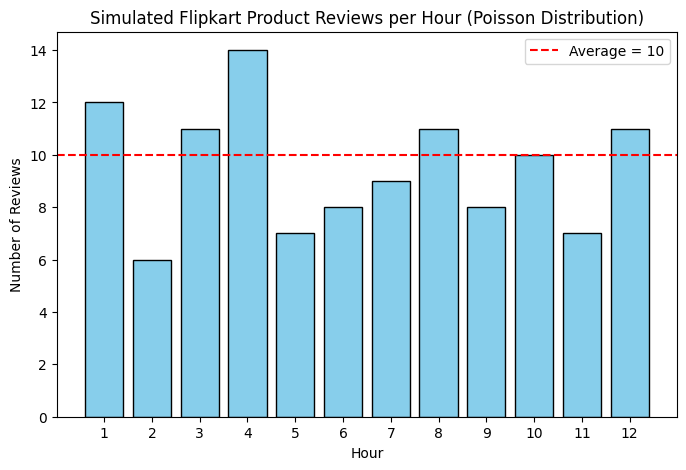

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # for reproducible results

avg_reviews_per_hour = 10
num_hours = 12

# Simulate number of reviews received in each of the 12 hours
reviews_per_hour = np.random.poisson(lam=avg_reviews_per_hour, size=num_hours)

print("Simulated reviews received in each hour:")
print(reviews_per_hour)

# Plot the results
hours = np.arange(1, num_hours + 1)

plt.figure(figsize=(8, 5))
plt.bar(hours, reviews_per_hour, color="skyblue", edgecolor="black")
plt.axhline(avg_reviews_per_hour, color="red", linestyle="--", label=f"Average = {avg_reviews_per_hour}")
plt.xlabel("Hour")
plt.ylabel("Number of Reviews")
plt.title("Simulated Flipkart Product Reviews per Hour (Poisson Distribution)")
plt.xticks(hours)
plt.legend()
plt.show()


**Explanation:** `np.random.poisson(lam=10, size=12)` simulates 12 random draws from a Poisson distribution with an average rate of 10 reviews per hour, giving a realistic hour-by-hour count that fluctuates around 10 (sometimes higher, sometimes lower) just like real review traffic would. The bar chart makes it easy to see this variation visually, with the red dashed line marking the average rate of 10 for comparison.

task 5

Pick any one of the three distributions (Bernoulli, Binomial, Poisson) and use ChatGPT to generate a real-world analytics use-case from a popular Indian app (like Swiggy, BookMyShow, or IRCTC). Paste the use-case ChatGPT gives you and explain in 2-3 lines why that distribution fits the scenario.

In [5]:
ai_generated_use_case = (
    "BookMyShow can use the Poisson distribution to model the number of ticket booking "
    "cancellations it receives per hour for a popular movie show. If historical data shows "
    "that on average 5 cancellations happen per hour for a given show, the Poisson distribution "
    "can be used to estimate the probability of receiving an unusually high number of "
    "cancellations (say, more than 10) in a given hour. This helps BookMyShow decide how many "
    "seats to release for last-minute booking or waitlisted customers, without overselling or "
    "leaving seats empty."
)

my_analysis = (
    "The Poisson distribution fits this scenario well because cancellations are discrete, "
    "independent events that occur randomly over a fixed time interval (one hour) at a known "
    "average rate, which is exactly the setting Poisson is designed for, rather than a fixed "
    "number of trials like a Binomial distribution would need."
)

print("AI-generated use-case:\n")
print(ai_generated_use_case)
print("\nMy own analysis:\n")
print(my_analysis)


AI-generated use-case:

BookMyShow can use the Poisson distribution to model the number of ticket booking cancellations it receives per hour for a popular movie show. If historical data shows that on average 5 cancellations happen per hour for a given show, the Poisson distribution can be used to estimate the probability of receiving an unusually high number of cancellations (say, more than 10) in a given hour. This helps BookMyShow decide how many seats to release for last-minute booking or waitlisted customers, without overselling or leaving seats empty.

My own analysis:

The Poisson distribution fits this scenario well because cancellations are discrete, independent events that occur randomly over a fixed time interval (one hour) at a known average rate, which is exactly the setting Poisson is designed for, rather than a fixed number of trials like a Binomial distribution would need.


**Explanation:** This task is conceptual, so the use-case and analysis are simply stored as text and printed. The chosen scenario uses the Poisson distribution for ticket cancellations at BookMyShow, and the explanation highlights why Poisson (rather than Bernoulli or Binomial) is the right fit — the event count isn't tied to a fixed number of trials, just a known average rate over a time window.